In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
data = pd.read_csv('/content/api_data_aadhar_enrolment_500000_1000000.csv')

print("Data loaded successfully. Here are the first 5 rows:")
display(data.head())

Data loaded successfully. Here are the first 5 rows:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,26-10-2025,Andhra Pradesh,Nalgonda,508004,0,1,0
1,26-10-2025,Andhra Pradesh,Nalgonda,508238,1,0,0
2,26-10-2025,Andhra Pradesh,Nalgonda,508278,1,0,0
3,26-10-2025,Andhra Pradesh,Nandyal,518432,0,1,0
4,26-10-2025,Andhra Pradesh,Nandyal,518543,1,0,0


In [ ]:
print("Here are the last 5 rows of the dataset:")
display(data.tail())

Here are the last 5 rows of the dataset:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
499995,31-12-2025,Telangana,Hyderabad,500045,4,5,1
499996,31-12-2025,Telangana,Hyderabad,500057,0,2,0
499997,31-12-2025,Telangana,Hyderabad,500061,4,2,0
499998,31-12-2025,Telangana,Hyderabad,500062,1,4,0
499999,31-12-2025,Telangana,Hyderabad,500095,0,1,0


In [ ]:
print("Dataset Information (data types, non-null values):")
data.info()

print(f"\nDataset Shape (Rows, Columns): {data.shape}")

Dataset Information (data types, non-null values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            500000 non-null  object
 1   state           500000 non-null  object
 2   district        500000 non-null  object
 3   pincode         500000 non-null  int64 
 4   age_0_5         500000 non-null  int64 
 5   age_5_17        500000 non-null  int64 
 6   age_18_greater  500000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 26.7+ MB

Dataset Shape (Rows, Columns): (500000, 7)


In [ ]:
print("Summary Statistics for Numerical Columns:")
display(data.describe())

Summary Statistics for Numerical Columns:


,pincode,age_0_5,age_5_17,age_18_greater
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,518077.362504,3.009628,1.082962,0.089984
std,204615.861812,4.658289,2.537596,1.073745
min,100000.000000,0.000000,0.000000,0.000000
25%,365541.000000,1.000000,0.000000,0.000000
50%,517583.000000,2.000000,0.000000,0.000000
75%,695023.000000,3.000000,1.000000,0.000000
max,855456.000000,210.000000,97.000000,318.000000


### Remove Duplicates


In [ ]:
print(f"Number of rows before removing duplicates: {data.shape[0]}")
data.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {data.shape[0]}")

Number of rows before removing duplicates: 500000
Number of rows after removing duplicates: 484196


In [ ]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')
data['state'] = data['state'].astype('category')
data['district'] = data['district'].astype('category')

print("Data types after conversion:")
data.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 484196 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            484196 non-null  datetime64[ns]
 1   state           484196 non-null  category      
 2   district        484196 non-null  category      
 3   pincode         484196 non-null  int64         
 4   age_0_5         484196 non-null  int64         
 5   age_5_17        484196 non-null  int64         
 6   age_18_greater  484196 non-null  int64         
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 23.6 MB


### Standardization of Text Data
Finally, I'll standardize the 'state' and 'district' columns by converting text to lowercase and stripping any leading/trailing whitespace to ensure consistency.

In [ ]:
data['state'] = data['state'].str.lower().str.strip()
data['district'] = data['district'].str.lower().str.strip()

print("First 5 rows after text standardization:")
display(data.head())

First 5 rows after text standardization:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-10-26,andhra pradesh,nalgonda,508004,0,1,0
1,2025-10-26,andhra pradesh,nalgonda,508238,1,0,0
2,2025-10-26,andhra pradesh,nalgonda,508278,1,0,0
3,2025-10-26,andhra pradesh,nandyal,518432,0,1,0
4,2025-10-26,andhra pradesh,nandyal,518543,1,0,0


In [ ]:
print("Unique states in the 'state' column before consolidation:")
display(data['state'].value_counts().sort_index())

Unique states in the 'state' column before consolidation:


,count
state,
100000,12
andaman & nicobar islands,47
andaman and nicobar islands,150
andhra pradesh,32749
arunachal pradesh,705
assam,14920
bihar,27974
chandigarh,435
chhattisgarh,9193


In [ ]:
# Define a mapping for known inconsistencies
state_name_mapping = {
    'odissa': 'orissa',
    'odisha': 'orissa'
}

# Apply the mapping to the 'state' column
data['state'] = data['state'].apply(lambda x: state_name_mapping.get(x, x))

# Convert back to category type after replacement to ensure efficiency and proper handling
data['state'] = data['state'].astype('category')

print("Unique states in the 'state' column after consolidation:")
display(data['state'].value_counts().sort_index())

print("\nConsolidation complete for 'odissa' and 'odisha' to 'orissa'.")

Unique states in the 'state' column after consolidation:


,count
state,
100000,12
andaman & nicobar islands,47
andaman and nicobar islands,150
andhra pradesh,32749
arunachal pradesh,705
assam,14920
bihar,27974
chandigarh,435
chhattisgarh,9193



Consolidation complete for 'odissa' and 'odisha' to 'orissa'.


### Removing anomalous state entry '100000'


In [ ]:
print(f"Number of rows before removing '100000' state: {data.shape[0]}")
data = data[data['state'] != '100000']
data['state'] = data['state'].cat.remove_unused_categories()
print(f"Number of rows after removing '100000' state: {data.shape[0]}")

print("\nUnique states after removing '100000':")
display(data['state'].value_counts().sort_index())

Number of rows before removing '100000' state: 484196
Number of rows after removing '100000' state: 484184

Unique states after removing '100000':


,count
state,
andaman & nicobar islands,47
andaman and nicobar islands,150
andhra pradesh,32749
arunachal pradesh,705
assam,14920
bihar,27974
chandigarh,435
chhattisgarh,9193
dadra & nagar haveli,11


### Consolidating more similar state names


In [ ]:
# Extend the mapping with more common inconsistencies
state_name_mapping_extended = {
    'andaman & nicobar islands': 'andaman and nicobar islands',
    'dadra & nagar haveli': 'dadra and nagar haveli and daman and diu',
    'dadra and nagar haveli': 'dadra and nagar haveli and daman and diu',
    'daman & diu': 'daman and diu',
    'jammu & kashmir': 'jammu and kashmir',
    'pondicherry': 'puducherry',
    'west  bengal': 'west bengal', # Two spaces
    'west bangal': 'west bengal', # Typo
    'westbengal': 'west bengal', # Typo
    # The previous mapping for odisha/odissa to orissa is already applied in `data['state']`, no need to re-add it here directly for `.get`
}

# Apply the extended mapping to the 'state' column
# Use a lambda function to handle cases where the key might not exist in the new mapping
# and preserve existing corrected values from previous steps (like 'orissa')
data['state'] = data['state'].apply(lambda x: state_name_mapping_extended.get(x, x))

# Also explicitly map existing longer D&N H and D&D to a shorter, consistent name
data['state'] = data['state'].replace({
    'dadra and nagar haveli and daman and diu': 'dadra and nagar haveli & daman and diu',
    'the dadra and nagar haveli and daman and diu': 'dadra and nagar haveli & daman and diu' # Assuming this is the same state
})

# Convert back to category type after replacement
data['state'] = data['state'].astype('category')

print("\nUnique states in the 'state' column after extended consolidation:")
display(data['state'].value_counts().sort_index())

print("\nExtended consolidation complete for common state name variations.")


Unique states in the 'state' column after extended consolidation:


,count
state,
andaman and nicobar islands,197
andhra pradesh,32749
arunachal pradesh,705
assam,14920
bihar,27974
chandigarh,435
chhattisgarh,9193
dadra and nagar haveli & daman and diu,134
daman and diu,61



Extended consolidation complete for common state name variations.


### Creating Aggregated Features


In [ ]:
# Create a new column 'total_registrations' by summing the age-group columns
data['total_registrations'] = data['age_0_5'] + data['age_5_17'] + data['age_18_greater']

print("DataFrame with 'total_registrations' column:")
display(data)

DataFrame with 'total_registrations' column:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
0,2025-10-26,andhra pradesh,nalgonda,508004,0,1,0,1
1,2025-10-26,andhra pradesh,nalgonda,508238,1,0,0,1
2,2025-10-26,andhra pradesh,nalgonda,508278,1,0,0,1
3,2025-10-26,andhra pradesh,nandyal,518432,0,1,0,1
4,2025-10-26,andhra pradesh,nandyal,518543,1,0,0,1
...,...,...,...,...,...,...,...,...
499995,2025-12-31,telangana,hyderabad,500045,4,5,1,10
499996,2025-12-31,telangana,hyderabad,500057,0,2,0,2
499997,2025-12-31,telangana,hyderabad,500061,4,2,0,6
499998,2025-12-31,telangana,hyderabad,500062,1,4,0,5


### Univariate Analysis: Numerical Features


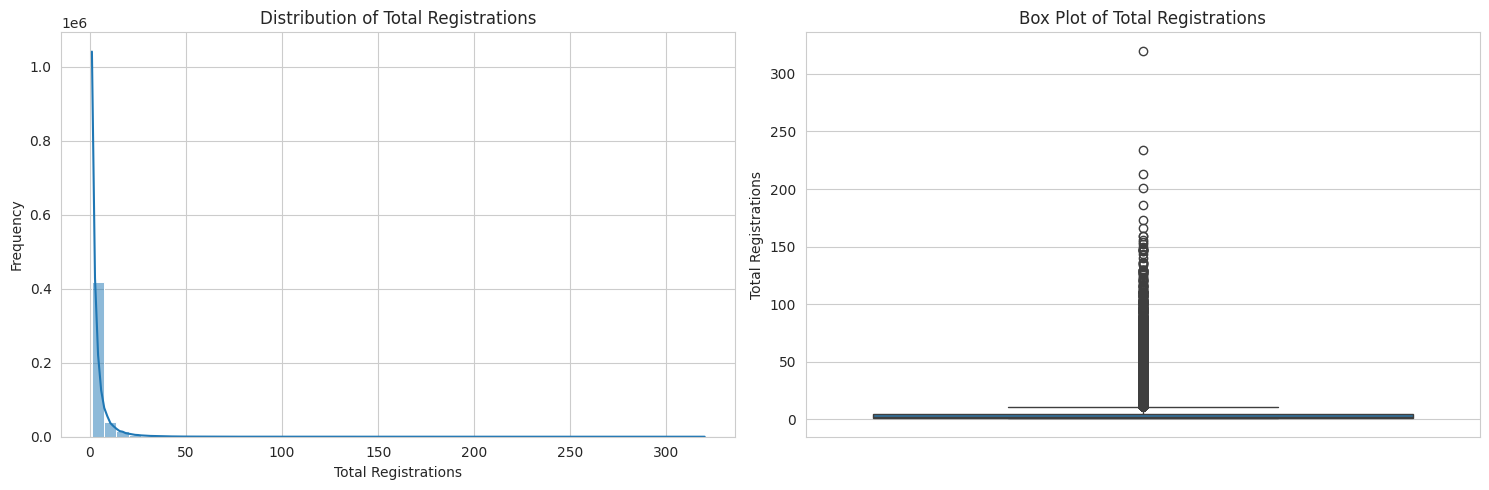

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))

# Histogram for total_registrations
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data['total_registrations'], bins=50, kde=True)
plt.title('Distribution of Total Registrations')
plt.xlabel('Total Registrations')
plt.ylabel('Frequency')

# Box plot for total_registrations
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=data['total_registrations'])
plt.title('Box Plot of Total Registrations')
plt.ylabel('Total Registrations')

plt.tight_layout()
plt.show()

Top 20 States by Number of Entries:


,count
state,
uttar pradesh,51104
tamil nadu,45702
maharashtra,37481
west bengal,35436
karnataka,35111
andhra pradesh,32749
bihar,27974
rajasthan,26463
madhya pradesh,25097


/tmp/ipython-input-1725375020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['state'], order=data['state'].value_counts().index[:20], palette='viridis')


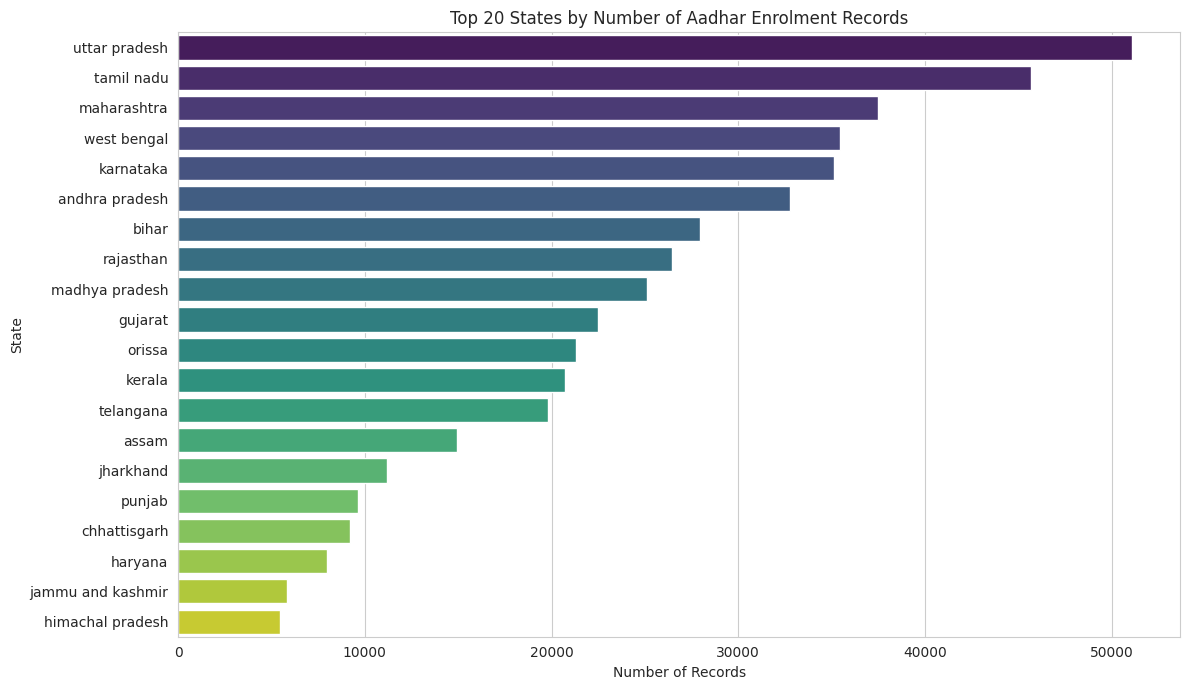

In [ ]:
print("Top 20 States by Number of Entries:")
display(data['state'].value_counts().head(20))

plt.figure(figsize=(12, 7))
sns.countplot(y=data['state'], order=data['state'].value_counts().index[:20], palette='viridis')
plt.title('Top 20 States by Number of Aadhar Enrolment Records')
plt.xlabel('Number of Records')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Top 20 Districts by Number of Entries:


,count
district,
pune,3252
north 24 parganas,3021
bengaluru,2604
barddhaman,2527
hyderabad,2437
malappuram,2422
thrissur,2239
south 24 parganas,2229
jaipur,2214


/tmp/ipython-input-3921865718.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['district'], order=data['district'].value_counts().index[:20], palette='magma')


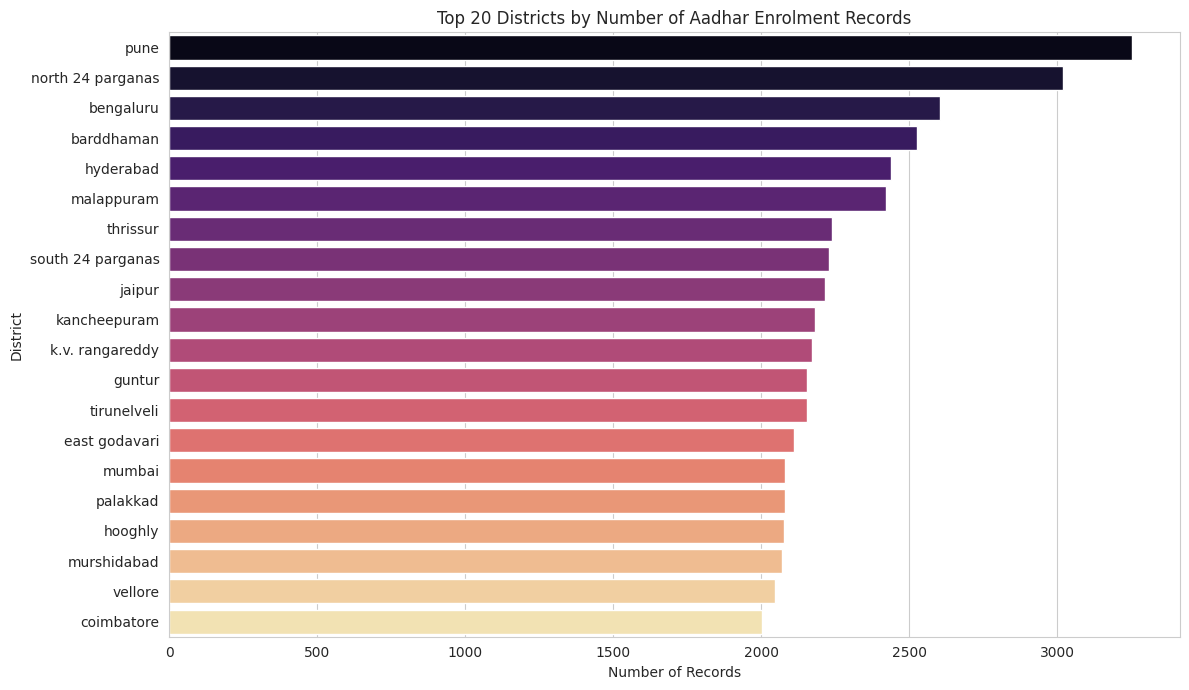

In [ ]:
print("Top 20 Districts by Number of Entries:")
display(data['district'].value_counts().head(20))

plt.figure(figsize=(12, 7))
sns.countplot(y=data['district'], order=data['district'].value_counts().index[:20], palette='magma')
plt.title('Top 20 Districts by Number of Aadhar Enrolment Records')
plt.xlabel('Number of Records')
plt.ylabel('District')
plt.tight_layout()
plt.show()

Finally, let's consider the `date` column. We can examine the trend of total registrations over time.

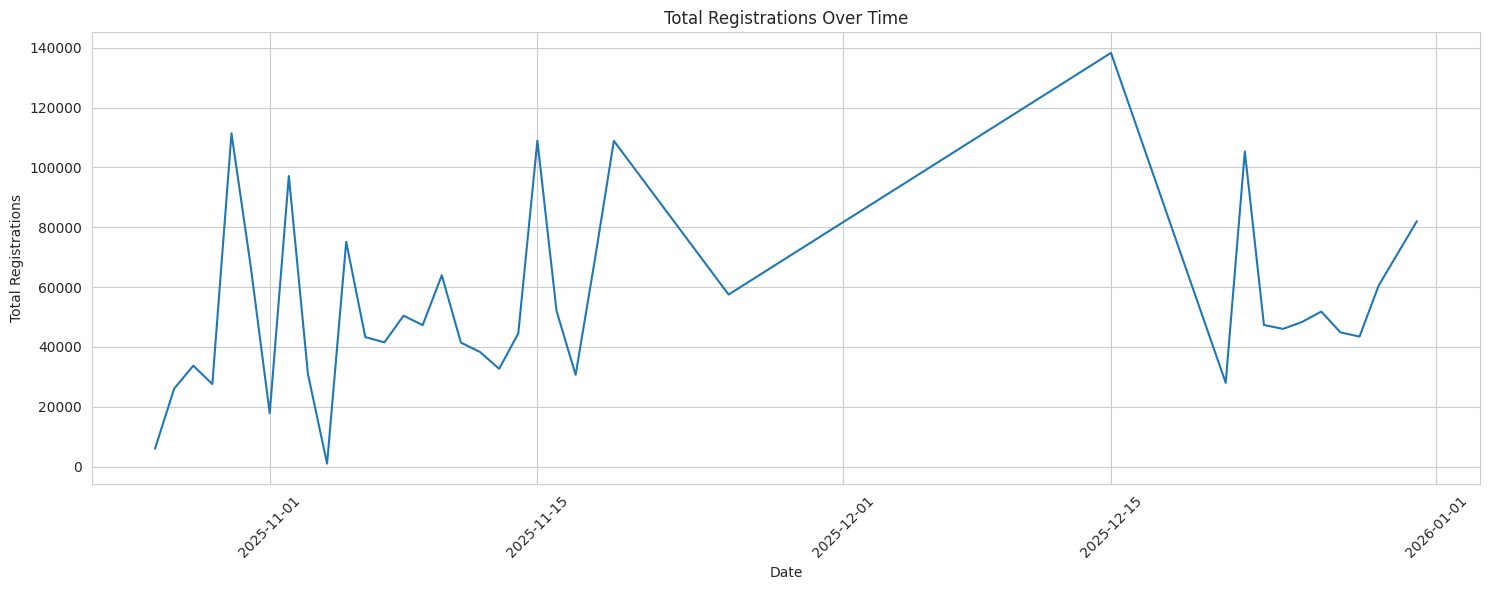

In [ ]:
# Aggregate total registrations by date
daily_registrations = data.groupby('date')['total_registrations'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(x='date', y='total_registrations', data=daily_registrations)
plt.title('Total Registrations Over Time')
plt.xlabel('Date')
plt.ylabel('Total Registrations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the cleaned DataFrame to a new CSV file
data.to_csv('aadhar_enrollment_cleaned_1.csv', index=False)

print("Data successfully saved to 'aadhar_enrollment_cleaned_1.csv'")

Data successfully saved to 'aadhar_enrollment_cleaned_1.csv'


In [ ]:
print("Here are the first 5 rows of the new dataset:")
display(data.head())

Here are the first 5 rows of the new dataset:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
0,2025-10-26,andhra pradesh,nalgonda,508004,0,1,0,1
1,2025-10-26,andhra pradesh,nalgonda,508238,1,0,0,1
2,2025-10-26,andhra pradesh,nalgonda,508278,1,0,0,1
3,2025-10-26,andhra pradesh,nandyal,518432,0,1,0,1
4,2025-10-26,andhra pradesh,nandyal,518543,1,0,0,1


In [ ]:
print("Here are the last 5 rows of the new dataset:")
display(data.tail())

Here are the last 5 rows of the new dataset:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
499995,2025-12-31,telangana,hyderabad,500045,4,5,1,10
499996,2025-12-31,telangana,hyderabad,500057,0,2,0,2
499997,2025-12-31,telangana,hyderabad,500061,4,2,0,6
499998,2025-12-31,telangana,hyderabad,500062,1,4,0,5
499999,2025-12-31,telangana,hyderabad,500095,0,1,0,1


In [ ]:
print("New Dataset Information (data types, non-null values):")
data.info()

print(f"\nNew Dataset Shape (Rows, Columns): {data.shape}")

New Dataset Information (data types, non-null values):
<class 'pandas.core.frame.DataFrame'>
Index: 484184 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 484184 non-null  datetime64[ns]
 1   state                484184 non-null  category      
 2   district             484184 non-null  object        
 3   pincode              484184 non-null  int64         
 4   age_0_5              484184 non-null  int64         
 5   age_5_17             484184 non-null  int64         
 6   age_18_greater       484184 non-null  int64         
 7   total_registrations  484184 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(5), object(1)
memory usage: 30.0+ MB

New Dataset Shape (Rows, Columns): (484184, 8)


In [ ]:
print("Summary Statistics for Numerical Columns in the new dataset:")
display(data.describe())

Summary Statistics for Numerical Columns in the new dataset:


,date,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
count,484184,484184.000000,484184.000000,484184.000000,484184.000000,484184.000000
mean,2025-11-22 20:50:32.189415424,517617.486538,3.004124,1.079521,0.089652,4.173298
min,2025-10-26 00:00:00,110001.000000,0.000000,0.000000,0.000000,1.000000
25%,2025-11-05 00:00:00,365456.000000,1.000000,0.000000,0.000000,1.000000
50%,2025-11-15 00:00:00,517520.000000,2.000000,0.000000,0.000000,2.000000
75%,2025-12-21 00:00:00,691533.000000,3.000000,1.000000,0.000000,5.000000
max,2025-12-31 00:00:00,855456.000000,210.000000,97.000000,318.000000,320.000000
std,NaN,204095.558032,4.654516,2.536365,1.057968,6.242157


In [ ]:
data = pd.read_csv('/content/api_data_aadhar_enrolment_1000000_1006029.csv')
print("New data loaded successfully. Here are the first 5 rows:")
display(data.head())

New data loaded successfully. Here are the first 5 rows:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [ ]:
print(f"Number of rows before removing duplicates: {data.shape[0]}")
data.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {data.shape[0]}")

Number of rows before removing duplicates: 6029
Number of rows after removing duplicates: 6029


In [ ]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')
data['state'] = data['state'].astype('category')
data['district'] = data['district'].astype('category')

print("Data types after conversion:")
data.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6029 entries, 0 to 6028
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6029 non-null   datetime64[ns]
 1   state           6029 non-null   category      
 2   district        6029 non-null   category      
 3   pincode         6029 non-null   int64         
 4   age_0_5         6029 non-null   int64         
 5   age_5_17        6029 non-null   int64         
 6   age_18_greater  6029 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 276.8 KB


In [ ]:
data['state'] = data['state'].str.lower().str.strip()
data['district'] = data['district'].str.lower().str.strip()

print("First 5 rows after text standardization:")
display(data.head())

First 5 rows after text standardization:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-12-31,karnataka,bidar,585330,2,3,0
1,2025-12-31,karnataka,bidar,585402,6,0,0
2,2025-12-31,karnataka,bidar,585413,1,0,0
3,2025-12-31,karnataka,bidar,585418,1,2,0
4,2025-12-31,karnataka,bidar,585421,4,3,0


In [ ]:
print(f"Number of rows before removing duplicates: {data.shape[0]}")
data.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {data.shape[0]}")

Number of rows before removing duplicates: 6029
Number of rows after removing duplicates: 6029


In [ ]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')
data['state'] = data['state'].astype('category')
data['district'] = data['district'].astype('category')

print("Data types after conversion:")
data.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6029 entries, 0 to 6028
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6029 non-null   datetime64[ns]
 1   state           6029 non-null   category      
 2   district        6029 non-null   category      
 3   pincode         6029 non-null   int64         
 4   age_0_5         6029 non-null   int64         
 5   age_5_17        6029 non-null   int64         
 6   age_18_greater  6029 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 276.8 KB


In [ ]:
data['state'] = data['state'].str.lower().str.strip()
data['district'] = data['district'].str.lower().str.strip()

print("First 5 rows after text standardization:")
display(data.head())

First 5 rows after text standardization:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-12-31,karnataka,bidar,585330,2,3,0
1,2025-12-31,karnataka,bidar,585402,6,0,0
2,2025-12-31,karnataka,bidar,585413,1,0,0
3,2025-12-31,karnataka,bidar,585418,1,2,0
4,2025-12-31,karnataka,bidar,585421,4,3,0


In [ ]:
print(f"Number of rows before removing '100000' state: {data.shape[0]}")
data = data[data['state'] != '100000']
# Explicitly convert 'state' back to category after filtering
data['state'] = data['state'].astype('category')
data['state'] = data['state'].cat.remove_unused_categories()
print(f"Number of rows after removing '100000' state: {data.shape[0]}")

# Define a mapping for known inconsistencies (re-using the previous one)
state_name_mapping_extended = {
    'odissa': 'orissa',
    'odisha': 'orissa',
    'andaman & nicobar islands': 'andaman and nicobar islands',
    'dadra & nagar haveli': 'dadra and nagar haveli and daman and diu',
    'dadra and nagar haveli': 'dadra and nagar haveli and daman and diu',
    'daman & diu': 'daman and diu',
    'jammu & kashmir': 'jammu and kashmir',
    'pondicherry': 'puducherry',
    'west  bengal': 'west bengal', # Two spaces
    'west bangal': 'west bengal', # Typo
    'westbengal': 'west bengal', # Typo
}

# Apply the extended mapping to the 'state' column
data['state'] = data['state'].apply(lambda x: state_name_mapping_extended.get(x, x))

# Also explicitly map existing longer D&N H and D&D to a shorter, consistent name
data['state'] = data['state'].replace({
    'dadra and nagar haveli and daman and diu': 'dadra and nagar haveli & daman and diu',
    'the dadra and nagar haveli and daman and diu': 'dadra and nagar haveli & daman and diu' # Assuming this is the same state
})

# Convert back to category type after replacement
data['state'] = data['state'].astype('category')

print("\nUnique states in the 'state' column after extended consolidation:")
display(data['state'].value_counts().sort_index())

print("\nExtended consolidation complete for common state name variations.")

Number of rows before removing '100000' state: 6029
Number of rows after removing '100000' state: 6029

Unique states in the 'state' column after extended consolidation:


,count
state,
andhra pradesh,240
arunachal pradesh,8
assam,117
bihar,175
chandigarh,2
chhattisgarh,76
daman and diu,1
delhi,14
goa,8



Extended consolidation complete for common state name variations.


### Creating Aggregated Features (Re-application)


In [ ]:
# Create a new column 'total_registrations' by summing the age-group columns
data['total_registrations'] = data['age_0_5'] + data['age_5_17'] + data['age_18_greater']

print("DataFrame with 'total_registrations' column:")
display(data.head())

DataFrame with 'total_registrations' column:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
0,2025-12-31,karnataka,bidar,585330,2,3,0,5
1,2025-12-31,karnataka,bidar,585402,6,0,0,6
2,2025-12-31,karnataka,bidar,585413,1,0,0,1
3,2025-12-31,karnataka,bidar,585418,1,2,0,3
4,2025-12-31,karnataka,bidar,585421,4,3,0,7


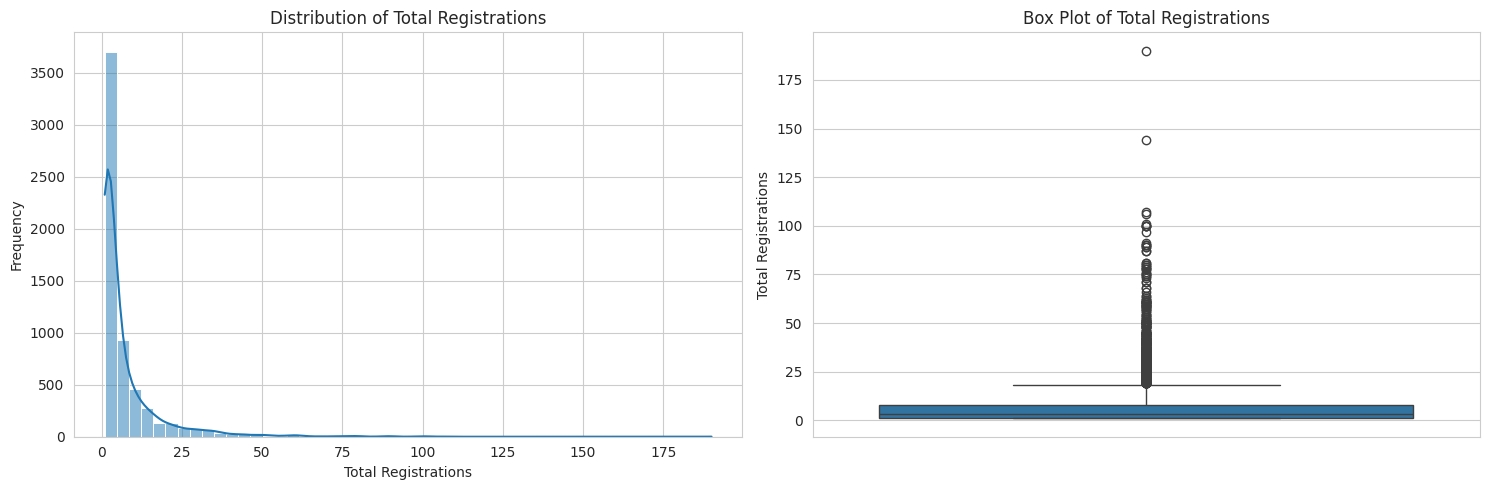

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))

# Histogram for total_registrations
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data['total_registrations'], bins=50, kde=True)
plt.title('Distribution of Total Registrations')
plt.xlabel('Total Registrations')
plt.ylabel('Frequency')

# Box plot for total_registrations
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=data['total_registrations'])
plt.title('Box Plot of Total Registrations')
plt.ylabel('Total Registrations')

plt.tight_layout()
plt.show()

Now, let's visualize the distributions of the individual age group columns (`age_0_5`, `age_5_17`, `age_18_greater`) using histograms and box plots to understand their patterns and identify any outliers for the new dataset.

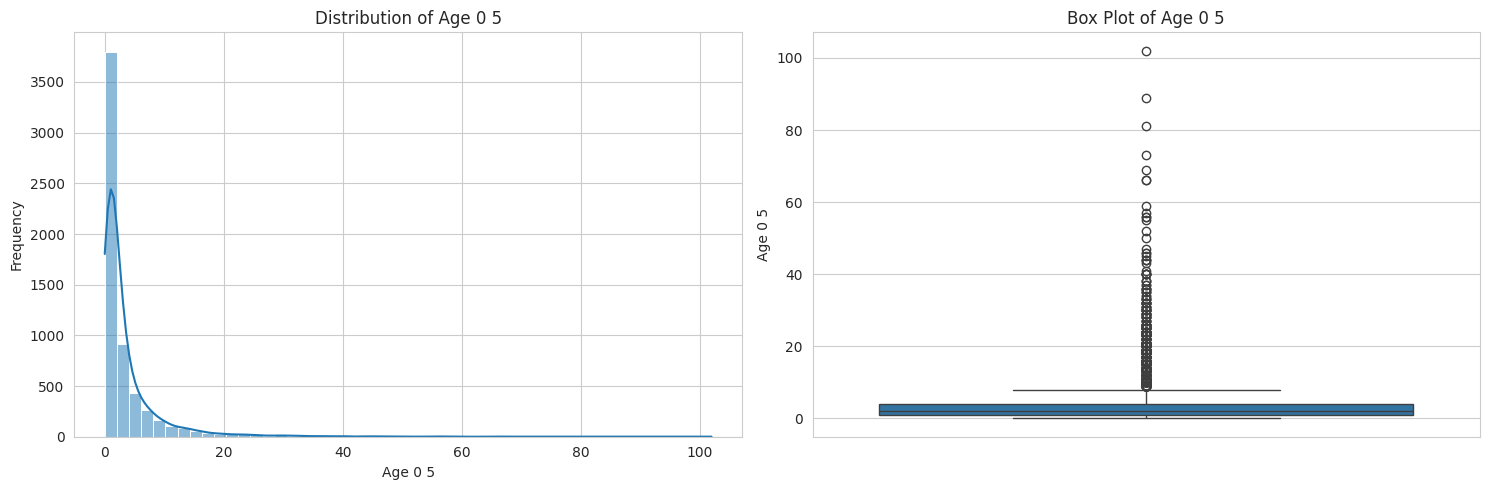

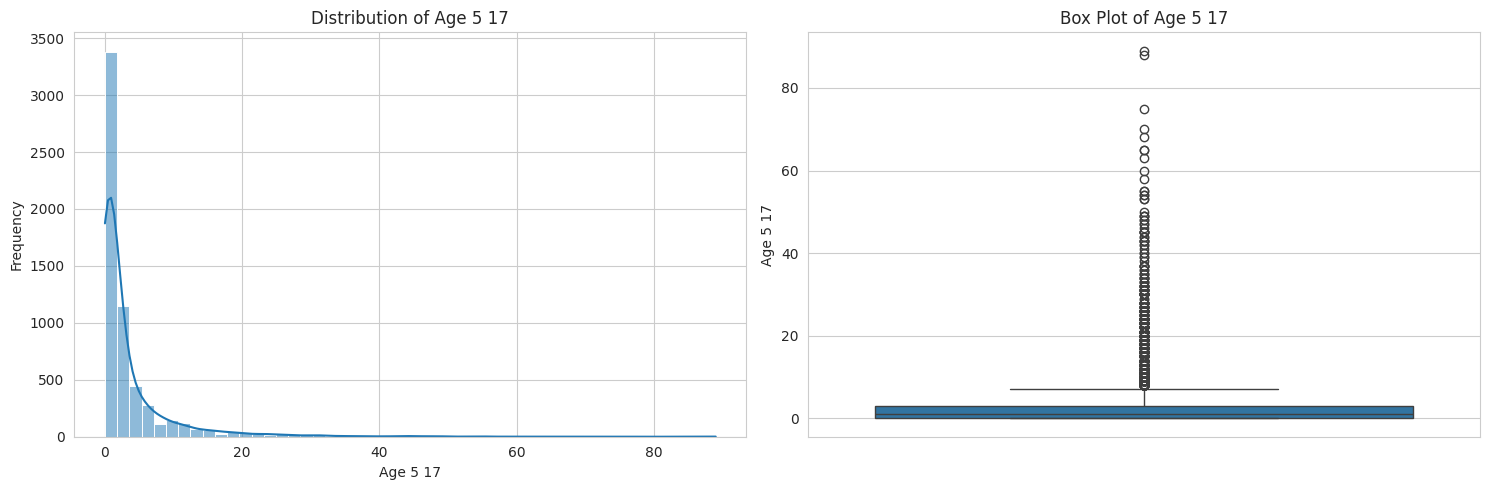

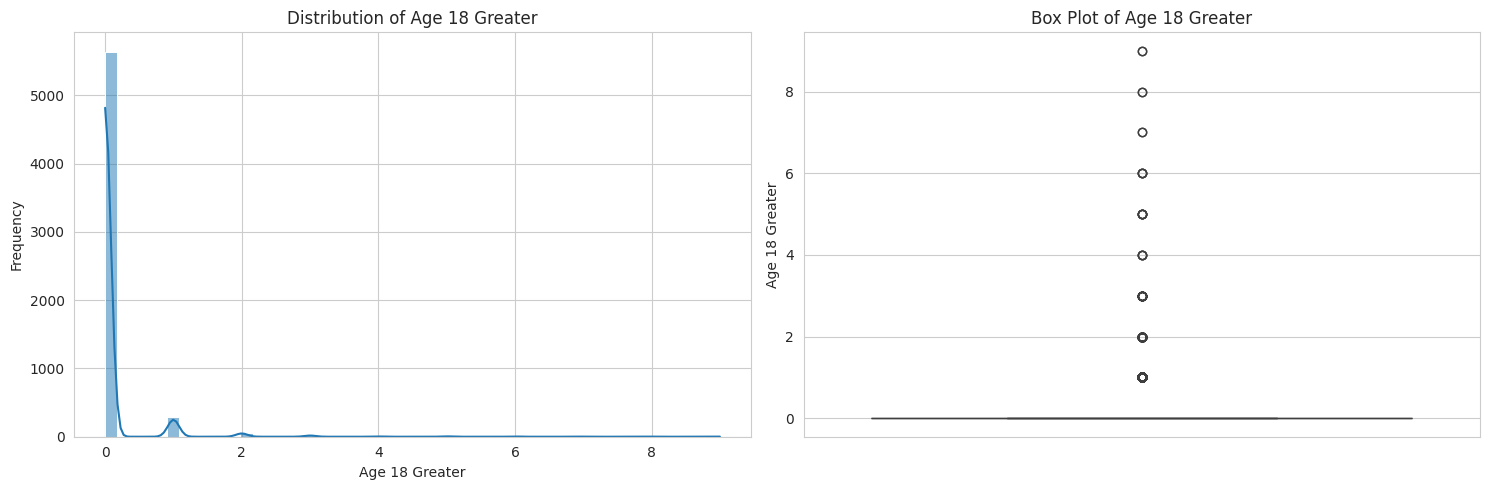

In [ ]:
numerical_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

for col in numerical_cols:
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

Top 20 States by Number of Entries:


,count
state,
uttar pradesh,713
tamil nadu,670
maharashtra,543
west bengal,534
karnataka,437
rajasthan,412
kerala,380
madhya pradesh,369
orissa,331


/tmp/ipython-input-1725375020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['state'], order=data['state'].value_counts().index[:20], palette='viridis')


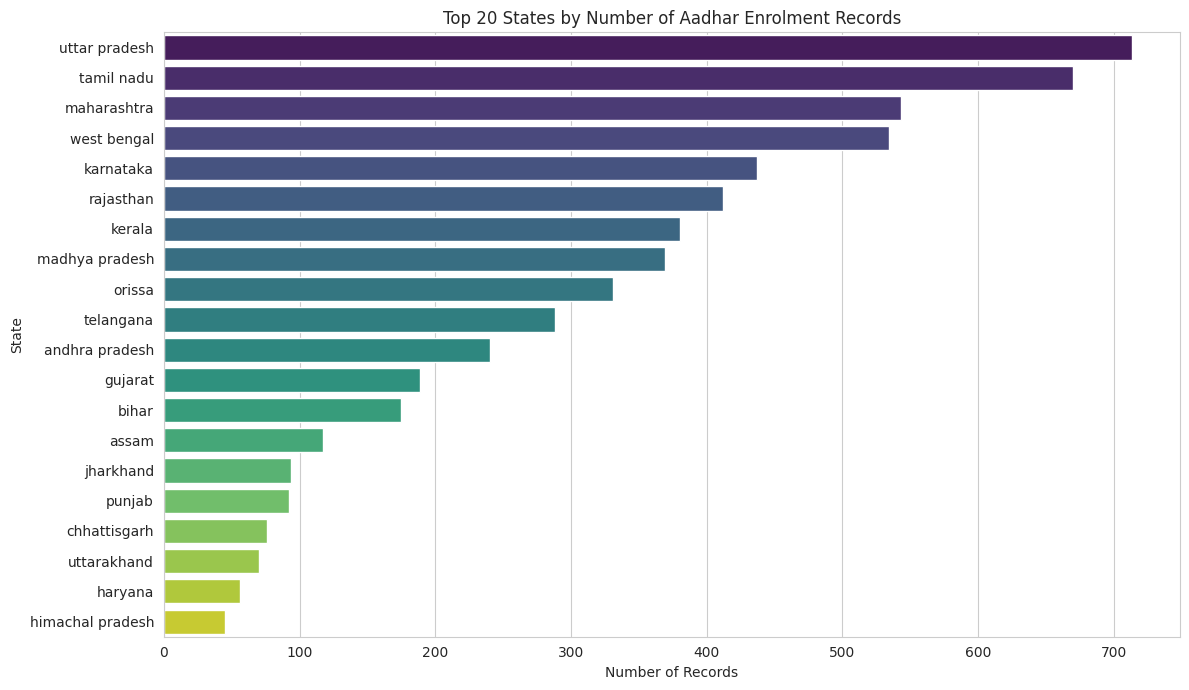

In [ ]:
print("Top 20 States by Number of Entries:")
display(data['state'].value_counts().head(20))

plt.figure(figsize=(12, 7))
sns.countplot(y=data['state'], order=data['state'].value_counts().index[:20], palette='viridis')
plt.title('Top 20 States by Number of Aadhar Enrolment Records')
plt.xlabel('Number of Records')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Top 20 Districts by Number of Entries:


,count
district,
pune,46
thrissur,44
malappuram,42
barddhaman,41
north 24 parganas,40
tiruchirappalli,38
tirunelveli,35
kannur,35
thanjavur,34


/tmp/ipython-input-3921865718.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['district'], order=data['district'].value_counts().index[:20], palette='magma')


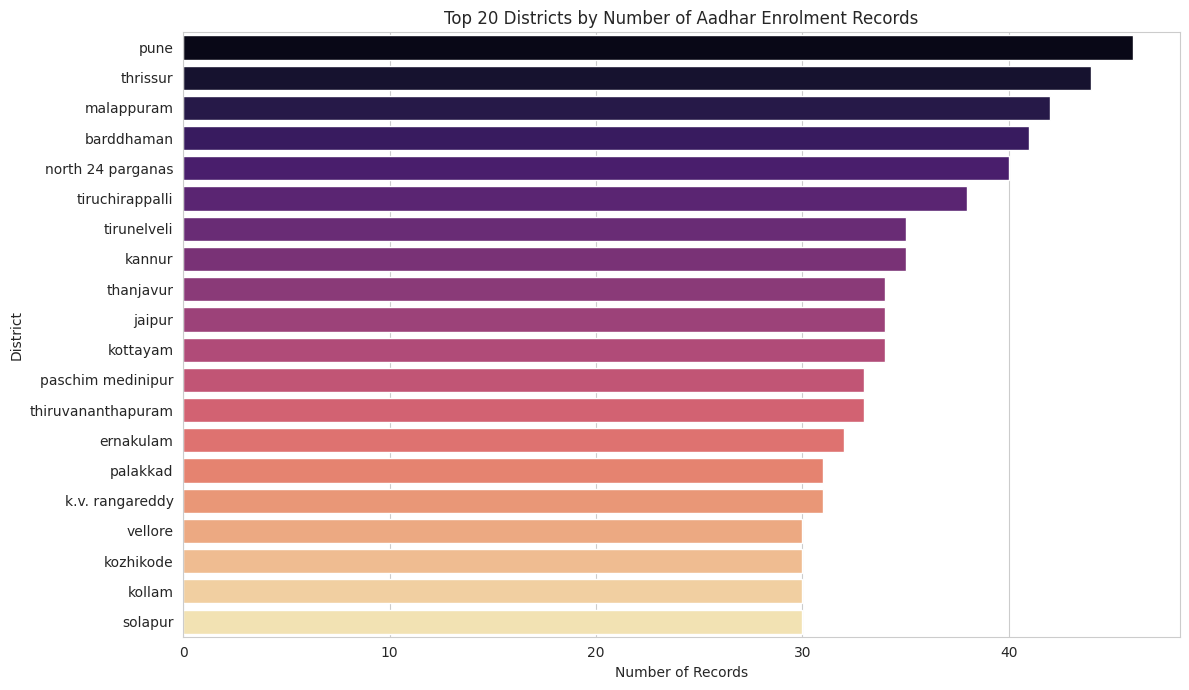

In [ ]:
print("Top 20 Districts by Number of Entries:")
display(data['district'].value_counts().head(20))

plt.figure(figsize=(12, 7))
sns.countplot(y=data['district'], order=data['district'].value_counts().index[:20], palette='magma')
plt.title('Top 20 Districts by Number of Aadhar Enrolment Records')
plt.xlabel('Number of Records')
plt.ylabel('District')
plt.tight_layout()
plt.show()

In [ ]:
print("Unique states in the 'state' column:")
display(data['state'].value_counts().sort_index())

Unique states in the 'state' column:


,count
state,
andhra pradesh,240
arunachal pradesh,8
assam,117
bihar,175
chandigarh,2
chhattisgarh,76
daman and diu,1
delhi,14
goa,8


In [ ]:
print(f"Number of rows before removing duplicates: {data.shape[0]}")
data.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {data.shape[0]}")

Number of rows before removing duplicates: 6029
Number of rows after removing duplicates: 6028


In [ ]:
data['date'] = pd.to_datetime(data['date'], format='%d-%m-%Y')
data['state'] = data['state'].astype('category')
data['district'] = data['district'].astype('category')

print("Data types after conversion:")
data.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 6028 entries, 0 to 6028
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 6028 non-null   datetime64[ns]
 1   state                6028 non-null   category      
 2   district             6028 non-null   category      
 3   pincode              6028 non-null   int64         
 4   age_0_5              6028 non-null   int64         
 5   age_5_17             6028 non-null   int64         
 6   age_18_greater       6028 non-null   int64         
 7   total_registrations  6028 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(5)
memory usage: 370.8 KB


In [ ]:
data['state'] = data['state'].str.lower().str.strip()
data['district'] = data['district'].str.lower().str.strip()

print("First 5 rows after text standardization:")
display(data.head())

First 5 rows after text standardization:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_registrations
0,2025-12-31,karnataka,bidar,585330,2,3,0,5
1,2025-12-31,karnataka,bidar,585402,6,0,0,6
2,2025-12-31,karnataka,bidar,585413,1,0,0,1
3,2025-12-31,karnataka,bidar,585418,1,2,0,3
4,2025-12-31,karnataka,bidar,585421,4,3,0,7


In [ ]:
# Define a new mapping to change 'orissa' to 'odisha'
state_name_reversion_mapping = {
    'orissa': 'odisha'
}

# Apply the mapping to the 'state' column
data['state'] = data['state'].apply(lambda x: state_name_reversion_mapping.get(x, x))

# Convert back to category type after replacement to ensure efficiency and proper handling
data['state'] = data['state'].astype('category')

print("Unique states in the 'state' column after updating 'orissa' to 'odisha':")
display(data['state'].value_counts().sort_index())

print("\nConsolidation complete: 'orissa' has been changed to 'odisha'.")

Unique states in the 'state' column after updating 'orissa' to 'odisha':


,count
state,
andhra pradesh,240
arunachal pradesh,8
assam,117
bihar,175
chandigarh,2
chhattisgarh,76
daman and diu,1
delhi,14
goa,8



Consolidation complete: 'orissa' has been changed to 'odisha'.
